# Explore the data

SAGE pairs presence-only occurrence records from GBIF (for training) with presence-absence vegetation plots from sPlotOpen (for evaluation), across 5,771 plant species worldwide.

This notebook is here to help you get a feel for that data. You'll look at the per-species property table, see how unevenly species are sampled, walk through the property space that the evaluation framework is built around, and inspect a few species up close.

Everything runs against the data you downloaded (`data_dir` in `configs/local_default.yaml`). Run the setup cell first.

> ⚠️ **Prerequisite — per-species range polygons.** This notebook draws each species' POWO native range, which is provided separately from the core data (it's large — only the map notebooks need it). Download `native_ranges.tar.gz` from the [Zenodo record](https://doi.org/10.5281/zenodo.21297133) and extract it into your `data_dir`:
>
> ```bash
> cd <your data_dir> && tar xzf native_ranges.tar.gz   # creates native_ranges/
> ```

In [ ]:
# Prerequisite check — per-species range polygons (see the note above).
import os, rootutils, yaml
rootutils.setup_root(os.path.abspath(""), indicator=".project-root", pythonpath=True, cwd=True)
_dd = yaml.safe_load(open("configs/local_default.yaml"))["data_dir"]
_nr = os.path.join(_dd, "native_ranges")
assert os.path.isdir(_nr) and os.listdir(_nr), (
    f"Native range polygons not found in {_nr}. Download native_ranges.tar.gz from the "
    f"Zenodo record and extract it into your data_dir:  cd {_dd} && tar xzf native_ranges.tar.gz"
)

In [1]:
import os
import rootutils
ROOT = rootutils.setup_root(os.path.abspath(""), indicator=".project-root", pythonpath=True, cwd=True)
import yaml
import pandas as pd
import matplotlib.pyplot as plt
data_dir = yaml.safe_load(open("configs/local_default.yaml"))["data_dir"]
props = pd.read_csv(f"{data_dir}/targets/species_properties_1km.csv")
print(f"{len(props):,} species  ·  reading from {data_dir}")

5,771 species  ·  reading from /path/to/data/


## The pieces

| Component | What it is |
|---|---|
| targets | presence/absence per species on a 1 km equal-area grid (GBIF for training, sPlotOpen for evaluation) |
| predictors | 52 environmental variables per location (CHELSA climate, SoilGrids, EarthEnv topography, Human Footprint) |
| range masks | each species' POWO native range; species are only evaluated inside it |
| `species_properties_1km.csv` | one row per species: taxonomy plus the data properties SAGE stratifies on |

## The species table

`species_properties_1km.csv` describes each species: its taxonomy plus the sampling properties.

In [2]:
props[["species_name", "family", "n_species_obs", "num_plots_in_range",
       "sampling_effort", "relative_prevalence"]].head()

,species_name,family,n_species_obs,num_plots_in_range,sampling_effort,relative_prevalence
0,Abies alba,Pinaceae,35506,16313,33.684586,2.691457
1,Abies amabilis,Pinaceae,1698,721,4.993575,1.026497
2,Abies balsamea,Pinaceae,11961,149,5.392809,3.389922
3,Abies concolor,Pinaceae,4233,11523,7.222629,1.549959
4,Abies fraseri,Pinaceae,201,1210,18.190329,0.320273


## How unevenly are species sampled?

Occurrence counts are very skewed. `data_stats` reproduces the paper's occurrence-distribution figure, showing the number of records per species. You'll see it three times: for the raw records, then after aggregating to the 1 km grid, then after subsampling. This loads the full targets matrix, so give it a moment.

Full: 89,768,890 total occurrences across 5,771 species
Aggregated (1 km): 57,084,636 total occurrences across 5,771 species
Subsampled (N=1000): 43,068,882 total occurrences across 5,771 species


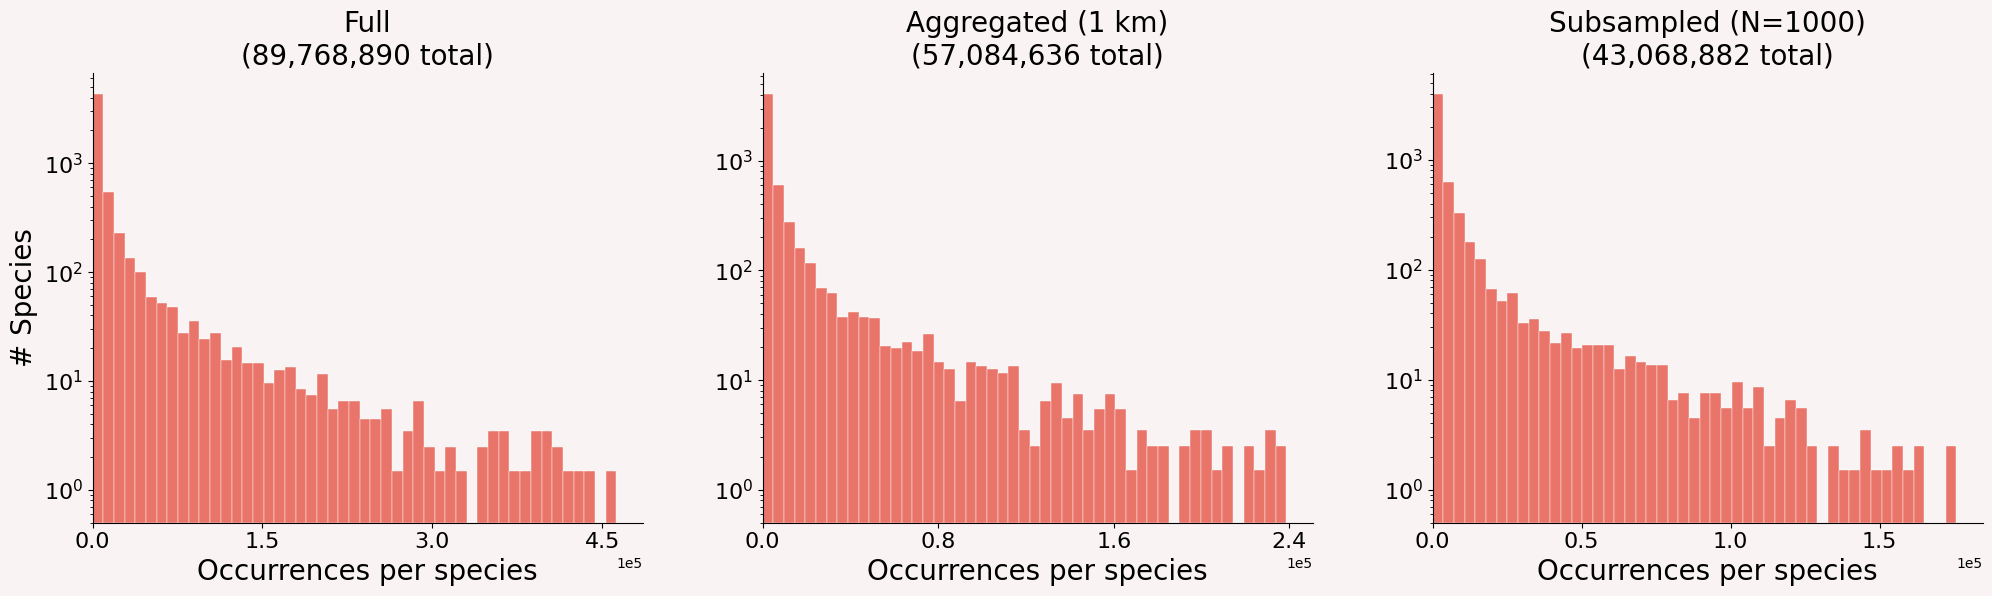

In [3]:
from src.visualizations.data_stats import plot_occurrence_distributions

# "full" reads targets/train_targets.h5, the pre-aggregation records, which ship in the
# optional sage_po_records_nonaggregated.tar. Skip that panel if you only extracted the
# core sage_benchmark_data.tar — the aggregation step is then just not shown.
levels = ["aggregated", "subsampled_1000"]
if os.path.exists(f"{data_dir}/targets/train_targets.h5"):
    levels.insert(0, "full")
else:
    print("targets/train_targets.h5 not found — showing the 1 km levels only.\n"
          "For the 'Full' panel, extract sage_po_records_nonaggregated.tar into your data_dir.")

plot_occurrence_distributions(data_dir, levels=levels, xscale="linear")
plt.show()

## The property space

SAGE describes each species with two properties, both computed from its training occurrences inside its native range:

- Sampling effort (SE): the fraction of the species' range cells that contain any occurrence record (sparse to dense).
- Relative prevalence (RP): of the *visited* range cells, the fraction where *that species* was recorded (infrequent to frequent).

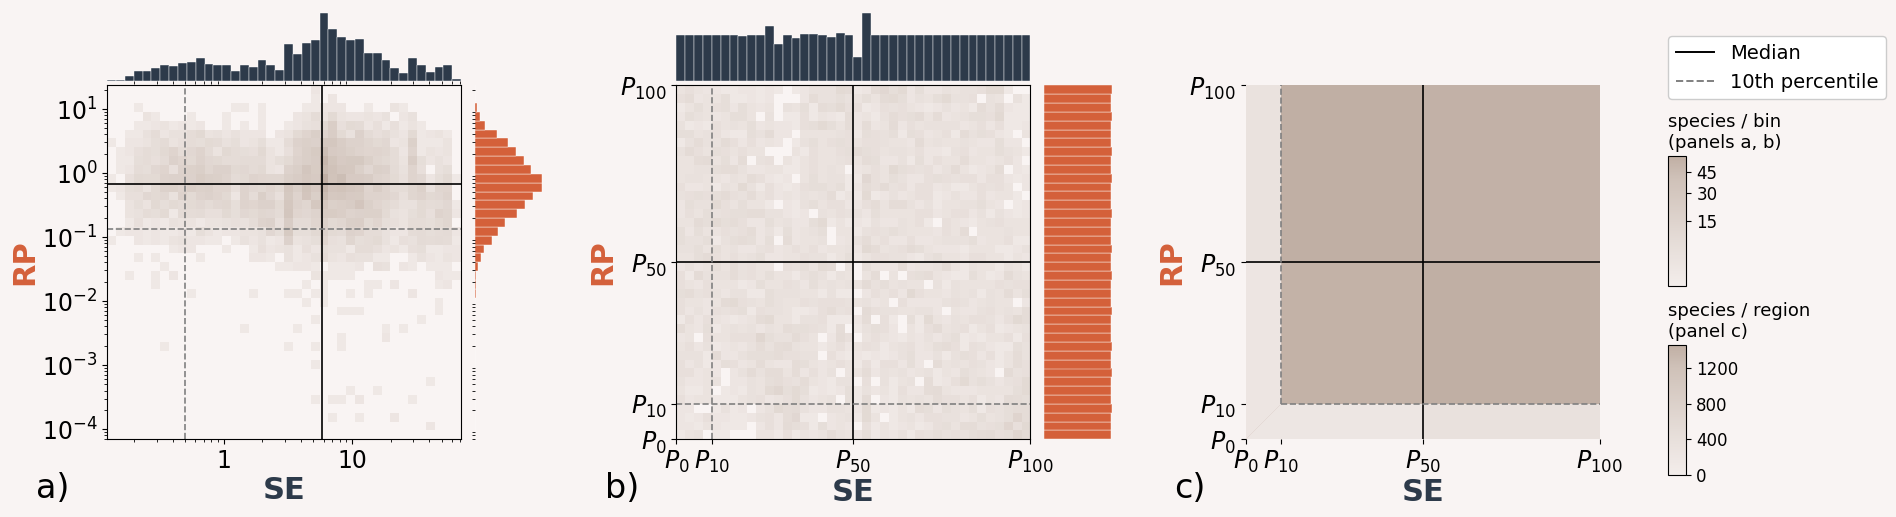

In [4]:
from src.visualizations.property_space import plot_property_space
plot_property_space(props)
plt.show()

## Two species in the property space

To make the space concrete, here are two Taiwanese species that sit in different regions. Both are densely sampled, but they fall at opposite ends of the *relative prevalence* axis. `species_map` colours every visited 1 km cell in the native range: navy means surveyed but this species absent, orange means present. The panel on the right marks where the species falls in the property space.

Look at the orange. *Aspidistra* is recorded in a small fraction of its surveyed cells (infrequent), while *Staphylea* turns up across far more of the same grid (frequent).

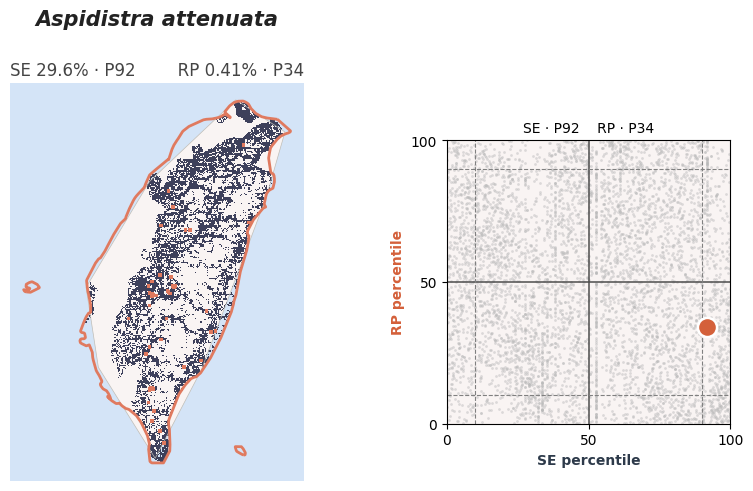

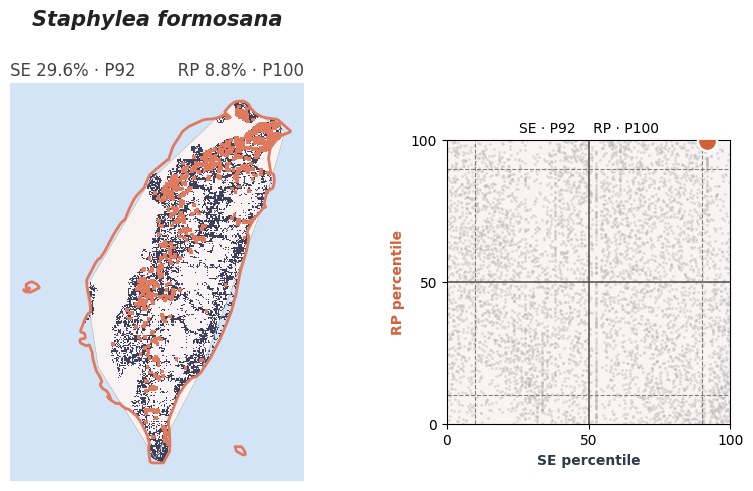

In [5]:
from src.visualizations.species_map import plot_species_occurrence_map
from src.visualizations.property_space import plot_species_in_quadrant

for species in ["Aspidistra attenuata", "Staphylea formosana"]:
    fig, (ax_map, ax_q) = plt.subplots(1, 2, figsize=(9, 5), gridspec_kw={"width_ratios": [2, 1]})
    plot_species_occurrence_map(species, data_dir, proxies=props, ax=ax_map)
    plot_species_in_quadrant(props, species, ax=ax_q)
    fig.tight_layout(); plt.show()

The orange presence cells are a small fraction of the surveyed range. Run the cell below for an interactive version.

In [6]:
from src.visualizations.species_map import plot_species_occurrence_map_plotly

# drag pans the map; the config enables mouse-wheel zoom
fig = plot_species_occurrence_map_plotly("Aspidistra attenuata", data_dir, proxies=props)
fig.show(config={"scrollZoom": True})

## Training vs evaluation data

For any one species you can also see the two data sources side by side: the GBIF training occurrences, the sPlotOpen evaluation plots, and the POWO native range the model is scored within. Here is *Fagus sylvatica* (European beech):

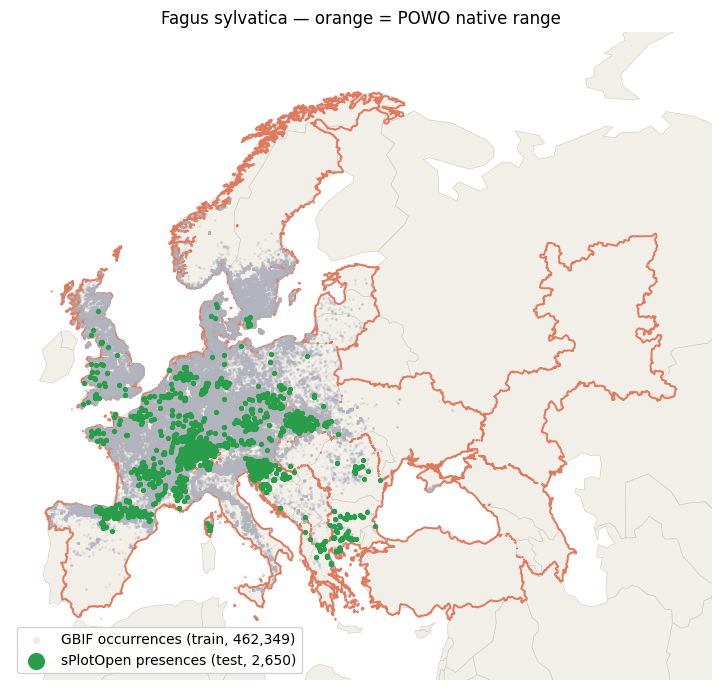

In [7]:
from src.visualizations.maps import load_species_data, load_splotopen_species_data, load_world_map

SPECIES = "Fagus sylvatica"
_, gbif_pres, range_gdf = load_species_data(SPECIES, data_dir)
_, splot_pres = load_splotopen_species_data(SPECIES, data_dir)
world = load_world_map(data_dir)

fig, ax = plt.subplots(figsize=(9, 7))
world.plot(ax=ax, color="#f2efe9", edgecolor="#cfc9bf", linewidth=0.4)
range_gdf.plot(ax=ax, facecolor="none", edgecolor="#E07A5F", linewidth=1.4)
ax.scatter(gbif_pres[:, 0], gbif_pres[:, 1], s=1, c="#b1b3bd", alpha=0.2,
           label=f"GBIF occurrences (train, {len(gbif_pres):,})")
ax.scatter(splot_pres[:, 0], splot_pres[:, 1], s=8, c="#2a9d4a",
           label=f"sPlotOpen presences (test, {len(splot_pres):,})")
minx, miny, maxx, maxy = range_gdf.total_bounds
ax.set_xlim(minx - 4, maxx + 4); ax.set_ylim(miny - 4, maxy + 4)
ax.set_title(f"{SPECIES} — orange = POWO native range")
ax.legend(markerscale=4, loc="lower left", framealpha=0.9); ax.set_axis_off()
plt.tight_layout(); plt.show()

## The predictors

Every 1 km cell carries 52 environmental predictors in four groups. Here are the exact variables:

| Group | # | Variables |
|---|---|---|
| CHELSA climate | 19 | `bio01`–`bio19`, the standard bioclim set (annual and seasonal temperature and precipitation) |
| SoilGrids | 8 | bulk density, cation-exchange capacity, clay, organic carbon, pH, silt, sand, depth-to-bedrock |
| EarthEnv topography | 16 | elevation, slope, aspect (cos/sin), roughness, TRI, TPI, VRM, eastness, northness, profile and tangential curvature, and the `dx / dy / dxx / dyy` derivatives |
| Global Human Footprint | 9 | overall footprint, built environments, croplands, night lights, navigable water, pasture, population density, railways, roads |

Models can also use location (lon/lat) through a location encoder. See [02 · Train a Model](02_train_a_model.ipynb).

## Where to next

- [02 · Train a Model](02_train_a_model.ipynb): train on it
- [03 · Evaluate Models](03_evaluate_models.ipynb): score models across the property space you just plotted